# Tracé des mesures — Sustentation MIMO
Représentation modale (3 axes) + vue physique (4 inducteurs)
## Import

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Nom du fichier généré par le script d'acquisition (lecture2.py)
MesTot = 'MesureSansIntervention.csv'

# Chargement des données avec Pandas
df = pd.read_csv(MesTot)

# Temps et signaux généraux
t = df['Temps(s)'].to_numpy()
frame_cnt = df['frameCnt'].to_numpy()
state = df['state'].to_numpy()

# --- Axes modaux (0, 1, 2) : représentation MIMO ---
modal = {}
for k in range(3):
    modal[k] = {
        'qm_ref': df[f'qm_ref_{k}(mm)'].to_numpy(),   # référence position modale
        'qm':     df[f'qm_{k}(mm)'].to_numpy(),       # position modale mesurée
        'vm_est': df[f'vm_est_{k}(mm/s)'].to_numpy(), # vitesse modale estimée
        'u_cmd':  df[f'u_cmd_{k}'].to_numpy(),         # commande avant saturation
        'u_sat':  df[f'u_sat_{k}'].to_numpy(),         # commande après saturation
        'integ':  df[f'integ_{k}'].to_numpy(),         # terme intégral LQI (LQI_EPS*eps_m)
    }

# --- Inducteurs physiques (1..4) ---
induc = {}
for i in range(1, 5):
    induc[i] = {
        'pos': df[f'Pos_{i}(mm)'].to_numpy(),  # position physique
        'fc':  df[f'fc_{i}'].to_numpy(),        # force consigne
        'cur': df[f'Cur_{i}(A)'].to_numpy(),    # courant
    }

## Tracé — Axes modaux (MIMO)

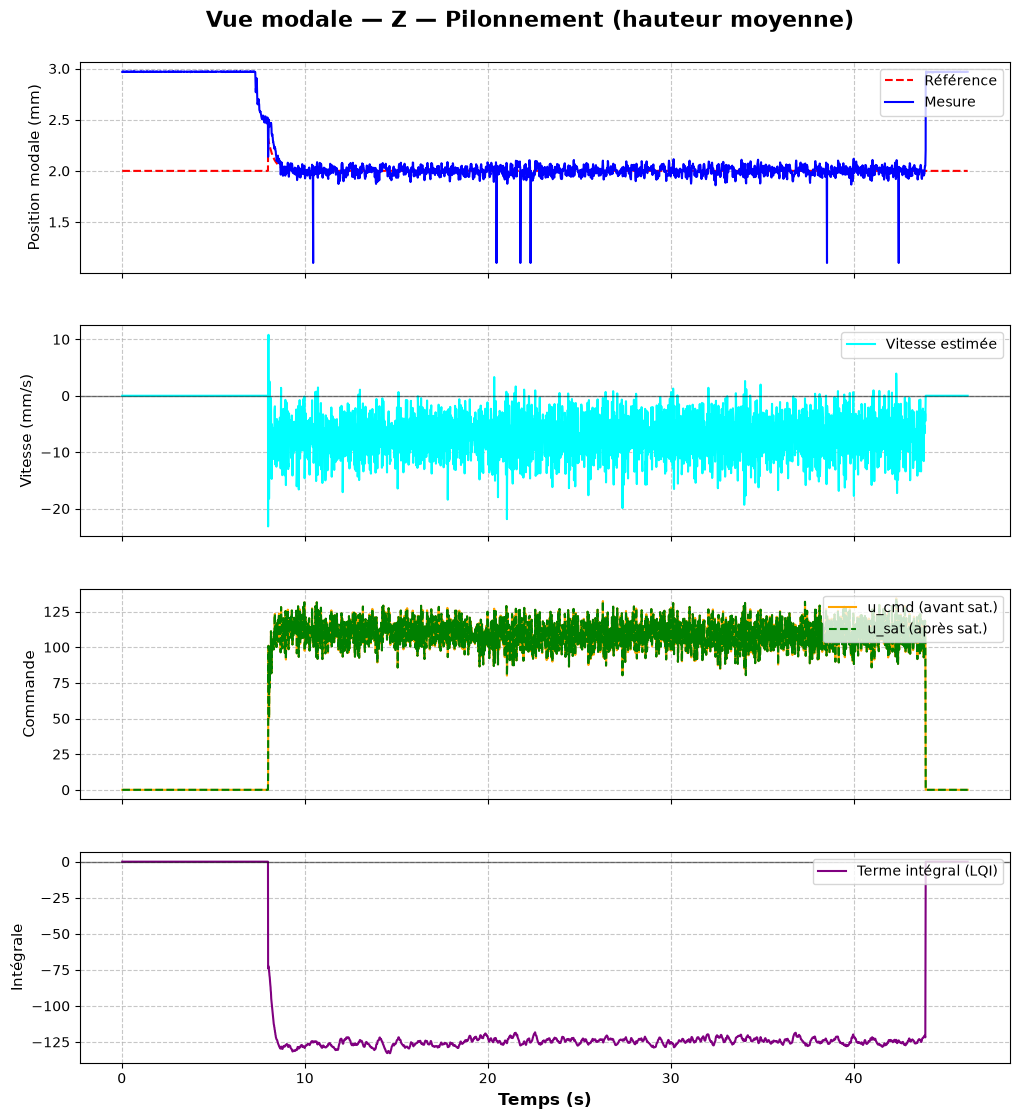

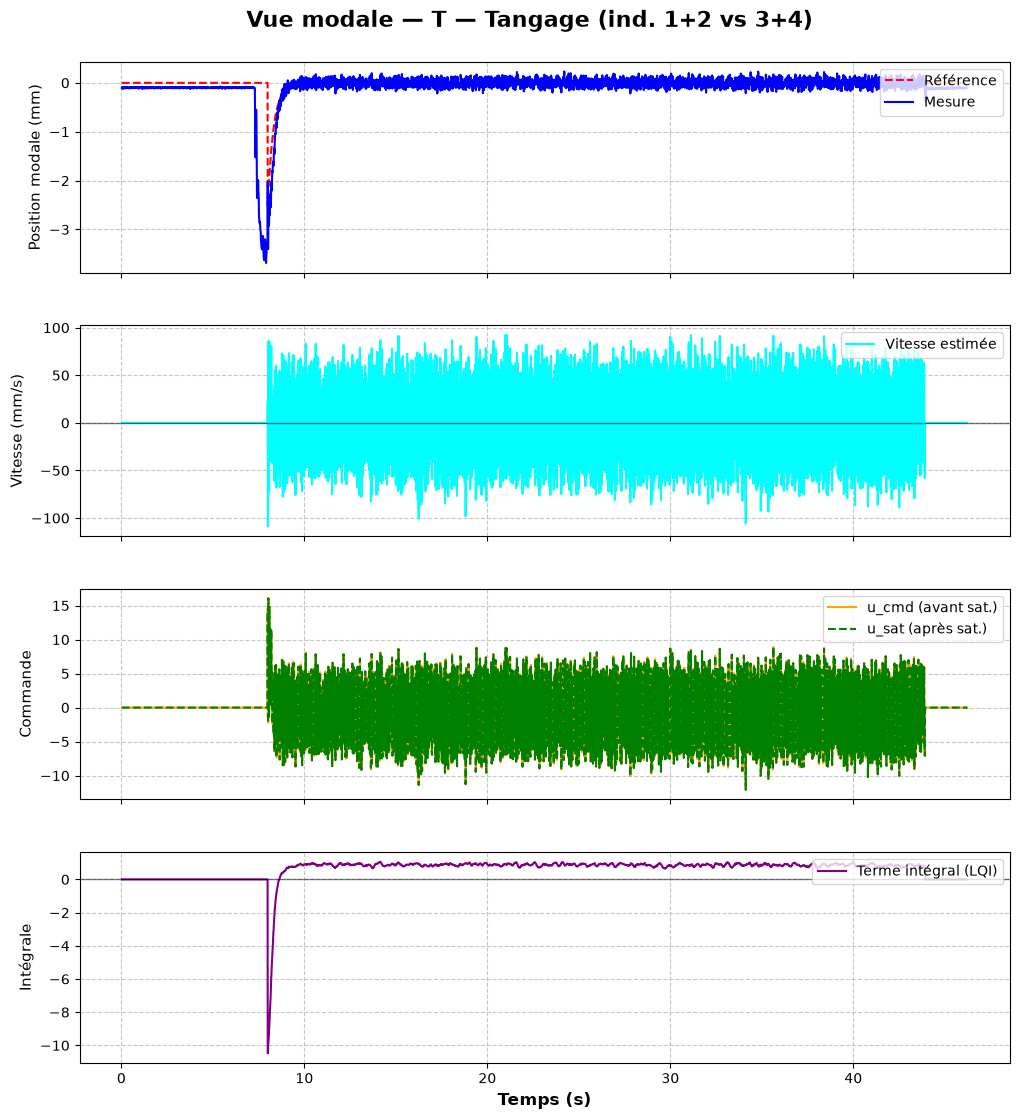

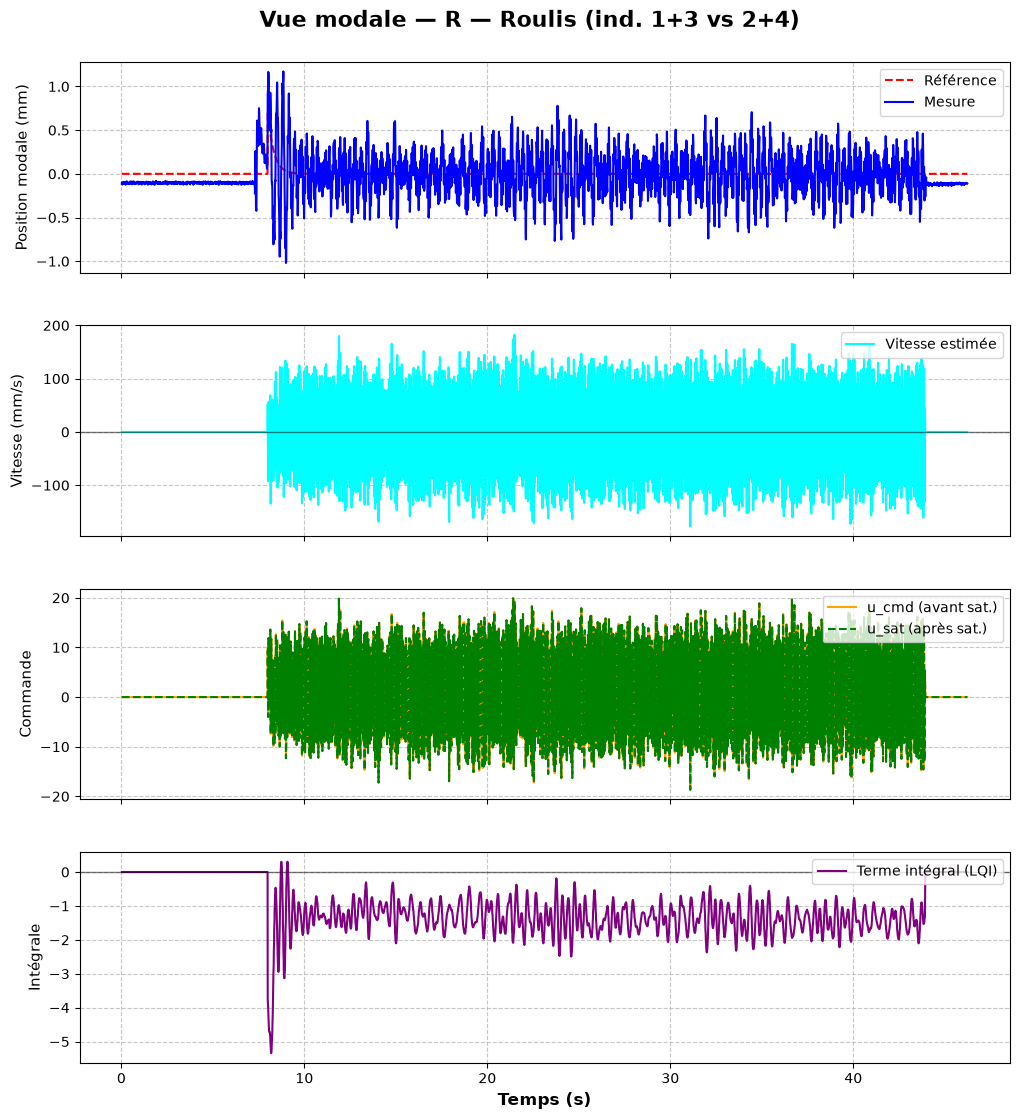

In [ ]:
# Titres physiques des axes modaux (cf. T_MAT dans Sustentation_Main.c : modes [Z, T, R])
noms_modaux = {
    0: "Hauteur",
    1: "Tangage (ind. 1+2 vs 3+4)",
    2: "Roulis (ind. 1+3 vs 2+4)",
}

# Tracé séparé pour chaque axe modal (0, 1, 2)
for k in range(3):
    d = modal[k]
    fig, axs = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

    # 1. Position modale : référence vs mesure
    axs[0].plot(t, d['qm_ref'], label='Référence', color='red', linestyle='--', linewidth=1.5)
    axs[0].plot(t, d['qm'], label='Mesure', color='blue', linewidth=1.5)
    axs[0].set_ylabel("Position modale (mm)", fontsize=11)
    axs[0].legend(loc="upper right")
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # 2. Vitesse modale estimée
    axs[1].plot(t, d['vm_est'], label='Vitesse estimée', color='cyan', linewidth=1.5)
    axs[1].axhline(0, color='black', linewidth=1, alpha=0.5)
    axs[1].set_ylabel("Vitesse (mm/s)", fontsize=11)
    axs[1].legend(loc="upper right")
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # 3. Commande : avant / après saturation
    axs[2].plot(t, d['u_cmd'], label='u_cmd (avant sat.)', color='orange', linewidth=1.5)
    axs[2].plot(t, d['u_sat'], label='u_sat (après sat.)', color='green', linestyle='--', linewidth=1.5)
    axs[2].set_ylabel("Commande", fontsize=11)
    axs[2].legend(loc="upper right")
    axs[2].grid(True, linestyle='--', alpha=0.7)

    # 4. Terme intégral LQI
    axs[3].plot(t, d['integ'], label='Terme intégral (LQI)', color='purple', linewidth=1.5)
    axs[3].axhline(0, color='black', linewidth=1, alpha=0.5)
    axs[3].set_ylabel("Intégrale", fontsize=11)
    axs[3].set_xlabel("Temps (s)", fontsize=12, fontweight='bold')
    axs[3].legend(loc="upper right")
    axs[3].grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"Vue modale — {noms_modaux[k]}", fontsize=16, fontweight='bold', y=0.92)
    plt.subplots_adjust(hspace=0.25)
    plt.show()

## Tracé — Inducteurs (vue physique)

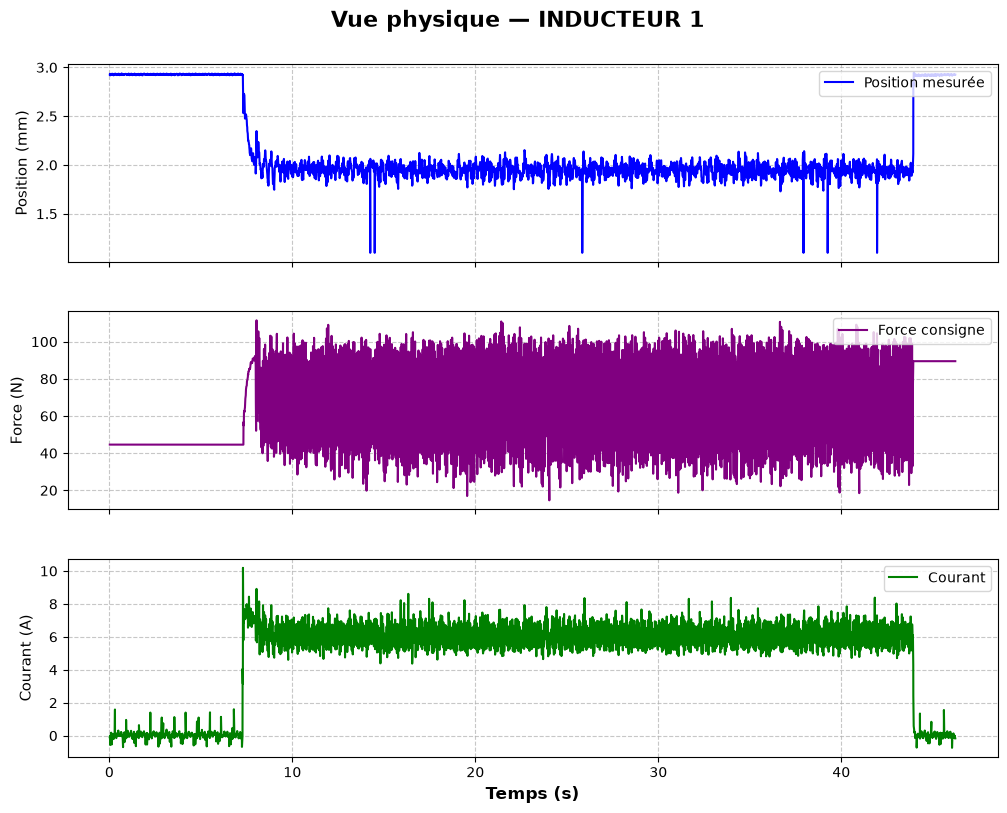

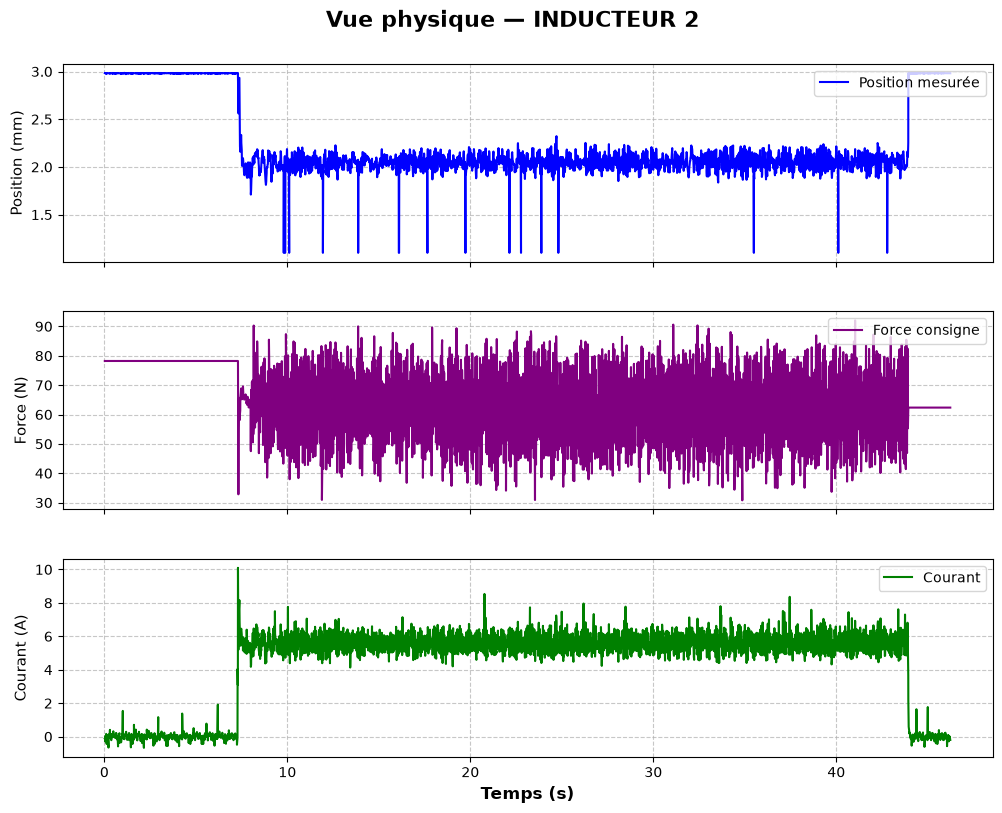

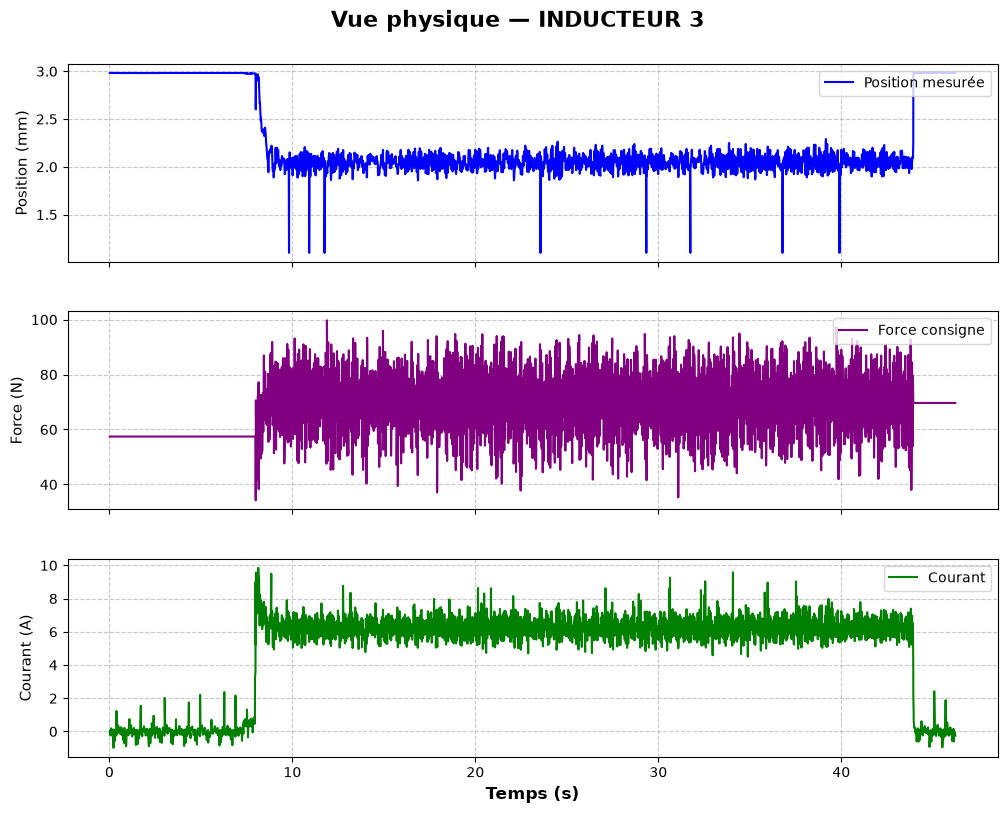

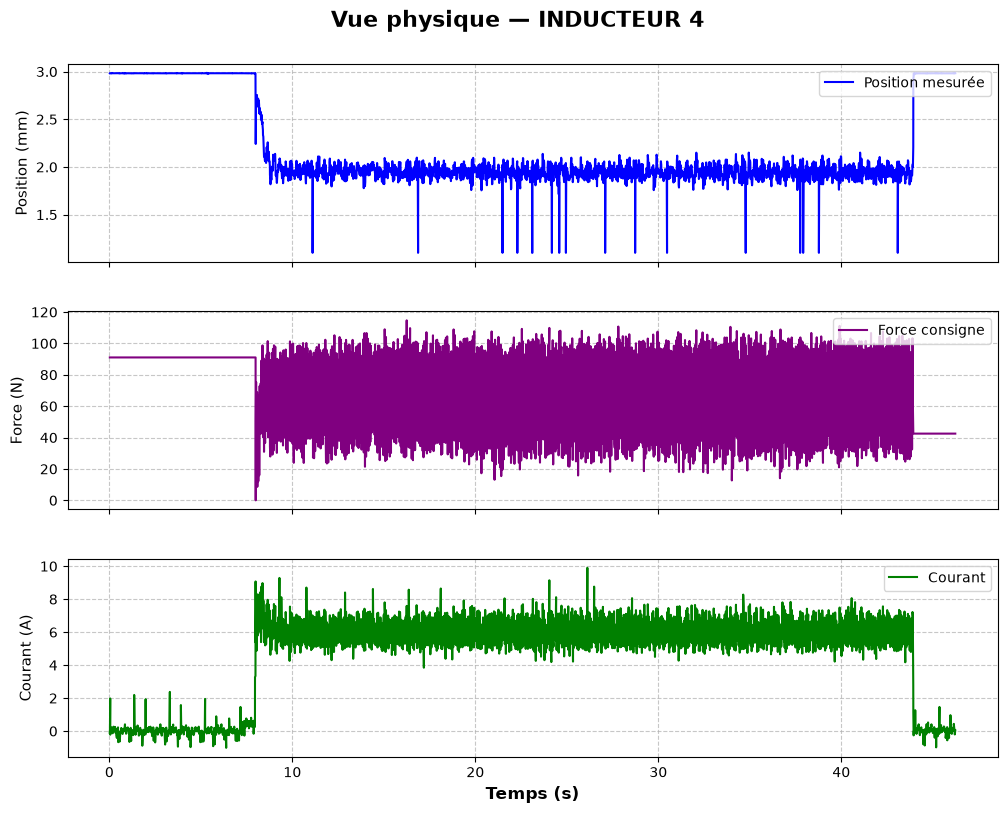

In [9]:
# Tracé séparé pour chaque inducteur physique (1..4)
for i in range(1, 5):
    d = induc[i]
    fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    # 1. Position physique mesurée
    axs[0].plot(t, d['pos'], label='Position mesurée', color='blue', linewidth=1.5)
    axs[0].set_ylabel("Position (mm)", fontsize=11)
    axs[0].legend(loc="upper right")
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # 2. Force consigne
    axs[1].plot(t, d['fc'], label='Force consigne', color='purple', linewidth=1.5)
    axs[1].set_ylabel("Force (N)", fontsize=11)
    axs[1].legend(loc="upper right")
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # 3. Courant
    axs[2].plot(t, d['cur'], label='Courant', color='green', linewidth=1.5)
    axs[2].set_ylabel("Courant (A)", fontsize=11)
    axs[2].set_xlabel("Temps (s)", fontsize=12, fontweight='bold')
    axs[2].legend(loc="upper right")
    axs[2].grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"Vue physique — INDUCTEUR {i}", fontsize=16, fontweight='bold', y=0.94)
    plt.subplots_adjust(hspace=0.25)
    plt.show()